1. 📦 Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

2. 📥 Load Data

In [20]:
df = pd.read_csv("train.csv")
# target
y = df["price"]
X = df.drop(["price"], axis=1)


3. 🧹 Handle Missing Values

In [21]:
# fill numeric missing values
num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# fill categorical missing values
cat_cols = X.select_dtypes(include="object").columns
X[cat_cols] = X[cat_cols].fillna("None")

In [22]:
binary_cols = [
    "mainroad", "guestroom", "basement",
    "hotwaterheating", "airconditioning", "prefarea"
]

for col in binary_cols:
   X[col] = X[col].map({"yes":1,"no":0})
 

In [23]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,2910,3,1,1,0,0,0,0,0,0,0,furnished


In [24]:
X = pd.get_dummies(X, columns=["furnishingstatus"], drop_first=True)

In [26]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [27]:
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

In [28]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,2910,3,1,1,0,0,0,0,0,0,0,0,0


5. 📏 Train/Test Split

In [29]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train)
# X_val = scaler.transform(X_val)

# # log transform target (recommended for house prices)
# y_train = np.log1p(y_train)
# y_val = np.log1p(y_val)

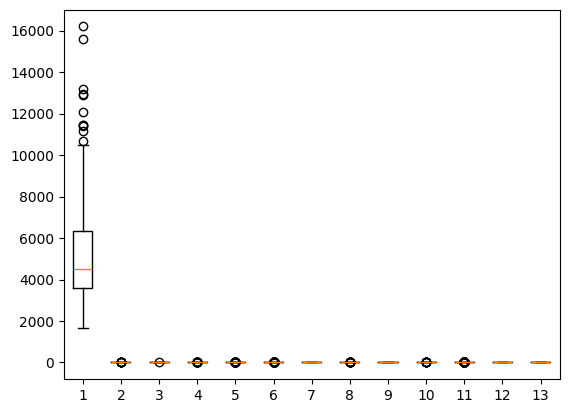

In [33]:
plt.boxplot(X_train)
plt.show()

✅ Option 1: Simple Gradient Boosting (sklearn)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

# Predict
pred = model.predict(X_val)

# Convert back from log
 
actual =  y_val 

# Evaluate
mae = mean_absolute_error(actual, pred)
mae_ratio = mae / actual.mean()

print("MAE:", mae)
print("MAE ratio:", mae_ratio)

MAE: 944108.7178837905
MAE ratio: 0.18853755348467066


🚀 Option 2 (Better): XGBoost

In [66]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1,
    random_state=42
)

model.fit(
    X_train, y_train,
 
)

pred  = model.predict(X_val)

 
actual =  y_val 

mae = mean_absolute_error(actual, pred)
mae_ratio = mae / actual.mean()

print("MAE ratio:", mae_ratio)
0.197664908765961

MAE ratio: 0.20871482091672827


0.197664908765961